# 10. CIR-процесс

**Статус:** завершено

CIR-процесс — положительная диффузия с возвратом к среднему. Его используют для процентных ставок, интенсивностей и стохастической дисперсии. Главная идея: шум пропорционален $\sqrt{X_t}$, поэтому около нуля случайность ослабевает.

## Модель

CIR задаётся SDE

$$dX_t=\kappa(\theta-X_t)dt+\sigma\sqrt{X_t}\,dW_t.$$

Как и OU, процесс тянется к $\theta$, но диффузионный член зависит от текущего уровня. Если $X_t$ мал, шум мал; если $X_t$ велик, шум сильнее.

Условие Феллера

$$2\kappa\theta\ge \sigma^2$$

гарантирует, что граница нуля недостижима для непрерывного процесса. Если условие нарушено, процесс всё ещё не становится отрицательным в точной модели, но может часто подходить близко к нулю.

Моменты:

$$\mathbb E[X_t]=\theta+(X_0-\theta)e^{-\kappa t}.$$

Стационарное распределение — gamma-распределение с shape $2\kappa\theta/\sigma^2$ и scale $\sigma^2/(2\kappa)$.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
project_root = Path.cwd().resolve()
while not (project_root / "Scripts").exists():
    if project_root.parent == project_root:
        raise RuntimeError("Не удалось найти корень проекта с папкой Scripts.")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

from Scripts.cir_process import (
    calculate_cir_feller_ratio,
    calculate_cir_stationary_gamma_parameters,
    calculate_theoretical_cir_mean_and_variance,
    plot_cir_mean_variance_comparison,
    plot_cir_paths,
    plot_cir_stationary_distribution,
    simulate_cir_paths_full_truncation_euler,
    simulate_cir_paths_plain_euler,
)

## 1. Положительный возврат к среднему

,Показатель,Значение
0,E[X(5)] симуляция,0.0501
1,E[X(5)] теория,0.0500
2,Var[X(5)] симуляция,0.0010
3,Var[X(5)] теория,0.0010
4,Feller ratio,2.4000
5,stationary shape,2.4000
6,stationary scale,0.0208
7,P(X(5)<0.005),0.0100


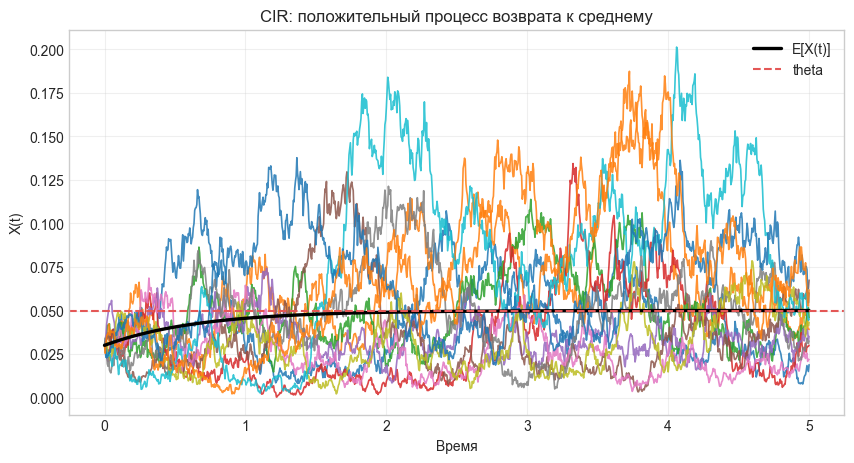

In [2]:
time_grid, cir_paths = simulate_cir_paths_full_truncation_euler(
    number_of_paths=6000,
    number_of_time_steps=1000,
    final_time=5.0,
    initial_value=0.03,
    mean_reversion_speed=1.5,
    long_term_mean=0.05,
    volatility=0.25,
    random_seed=123,
)
theoretical_mean, theoretical_variance = calculate_theoretical_cir_mean_and_variance(time_grid, 0.03, 1.5, 0.05, 0.25)
feller_ratio = calculate_cir_feller_ratio(1.5, 0.05, 0.25)
shape, scale = calculate_cir_stationary_gamma_parameters(1.5, 0.05, 0.25)

plot_cir_paths(time_grid, cir_paths, theoretical_mean, 0.05, "CIR: положительный процесс возврата к среднему");

pd.DataFrame({
    "Показатель": ["E[X(5)] симуляция", "E[X(5)] теория", "Var[X(5)] симуляция", "Var[X(5)] теория", "Feller ratio", "stationary shape", "stationary scale", "P(X(5)<0.005)"],
    "Значение": [cir_paths[:,-1].mean(), theoretical_mean[-1], cir_paths[:,-1].var(), theoretical_variance[-1], feller_ratio, shape, scale, np.mean(cir_paths[:,-1] < 0.005)]
})

Среднее к моменту `T=5` равно `0.0501`, теория даёт `0.0500`: процесс вернулся к уровню `theta=0.05`. Дисперсия `0.00105` близка к теоретической `0.00104`.

Feller ratio равен `2.4`, то есть условие Феллера выполнено. Поэтому процесс редко подходит очень близко к нулю: `P(X(5)<0.005)` около `0.01`. В отличие от OU, отрицательные значения здесь не являются естественной частью модели.

## 2. Моменты и стационарное gamma-распределение

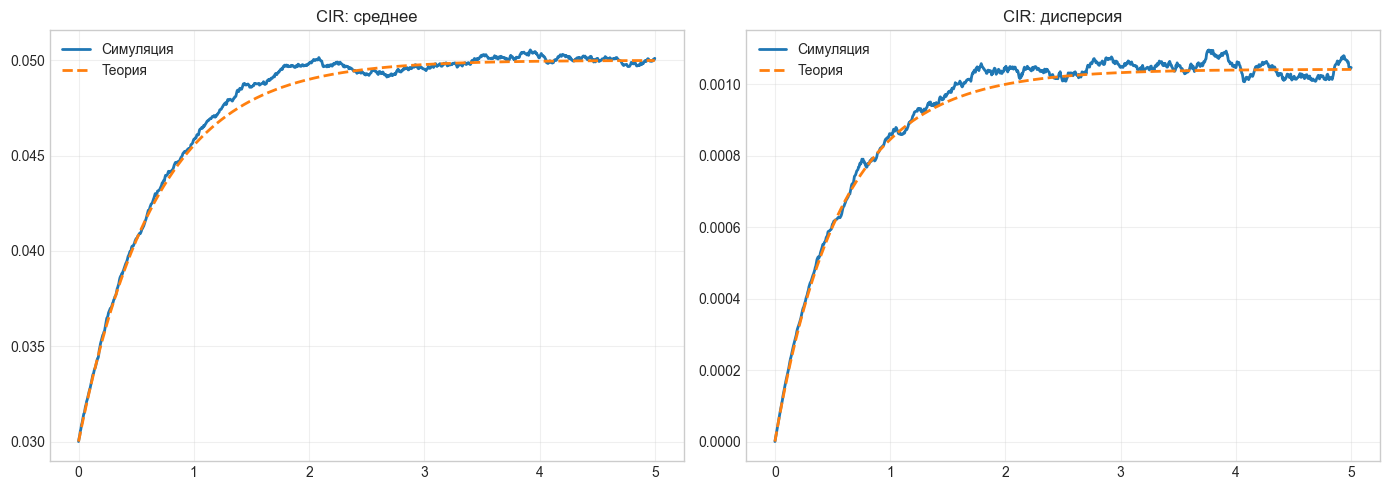

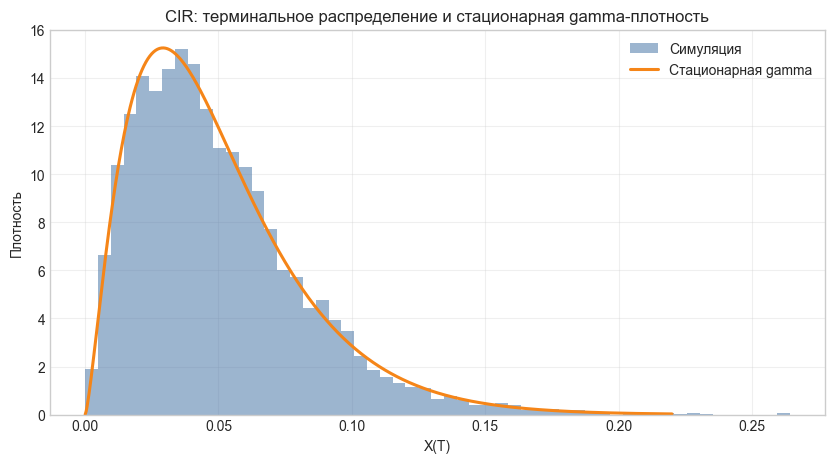

In [3]:
plot_cir_mean_variance_comparison(time_grid, cir_paths, theoretical_mean, theoretical_variance, "CIR");
plot_cir_stationary_distribution(cir_paths[:, -1], shape, scale, "CIR: терминальное распределение и стационарная gamma-плотность");

Стационарное распределение CIR не нормальное, а gamma: оно асимметрично и поддержано только на положительной полуоси. Это очень важно для процентных ставок и дисперсий: модель учитывает, что величина не должна уходить в отрицательную область.

## 3. Почему обычный Эйлер опасен

In [4]:
plain_time_grid, plain_euler_paths = simulate_cir_paths_plain_euler(
    number_of_paths=3000,
    number_of_time_steps=100,
    final_time=2.0,
    initial_value=0.01,
    mean_reversion_speed=1.0,
    long_term_mean=0.03,
    volatility=0.5,
    random_seed=456,
)
truncated_time_grid, truncated_paths = simulate_cir_paths_full_truncation_euler(
    number_of_paths=3000,
    number_of_time_steps=100,
    final_time=2.0,
    initial_value=0.01,
    mean_reversion_speed=1.0,
    long_term_mean=0.03,
    volatility=0.5,
    random_seed=456,
)

pd.DataFrame({
    "Схема": ["обычный Эйлер", "full truncation Euler"],
    "Доля отрицательных значений на сетке": [np.mean(plain_euler_paths < 0.0), np.mean(truncated_paths < 0.0)],
    "Минимальное значение": [plain_euler_paths.min(), truncated_paths.min()],
    "Среднее X(2)": [plain_euler_paths[:, -1].mean(), truncated_paths[:, -1].mean()],
})

,Схема,Доля отрицательных значений на сетке,Минимальное значение,Среднее X(2)
0,обычный Эйлер,0.2403,-0.0214,0.0268
1,full truncation Euler,0.0000,0.0000,0.0334


Обычный Эйлер дал отрицательные значения на сетке с долей `0.2403`, минимум `-0.0214`. Это численная проблема: точный CIR не уходит в отрицательную область, но дискретная схема может перескочить через ноль.

Full truncation Euler принудительно использует неотрицательное состояние в корне и обрезает результат снизу нулём. Это не идеальная точная схема, но она сохраняет ключевую экономическую интерпретацию положительности.

## 4. Сравнение с OU

In [5]:
scenario_rows = []
for sigma in [0.15, 0.25, 0.45]:
    scenario_time, scenario_paths = simulate_cir_paths_full_truncation_euler(3000, 800, 5.0, 0.03, 1.5, 0.05, sigma, random_seed=99)
    scenario_rows.append({"sigma": sigma, "E[X(5)]": scenario_paths[:, -1].mean(), "Var[X(5)]": scenario_paths[:, -1].var(), "P(X(5)<0.005)": np.mean(scenario_paths[:, -1] < 0.005), "Feller ratio": calculate_cir_feller_ratio(1.5,0.05,sigma)})

pd.DataFrame(scenario_rows)

,sigma,E[X(5)],Var[X(5)],P(X(5)<0.005),Feller ratio
0,0.15,0.0498,0.0004,0.0000,6.6667
1,0.25,0.0498,0.0011,0.0107,2.4000
2,0.45,0.0505,0.0035,0.1567,0.7407


При росте $\sigma$ дисперсия увеличивается, а Feller ratio падает. Когда Feller ratio становится меньше 1, процесс чаще подходит к нулю. Это отличие от OU: в OU шум одинаковый везде, а в CIR шум зависит от уровня и сам затухает около нуля.

## Выводы

1. CIR — положительная mean-reverting диффузия.
2. Шум $\sigma\sqrt{X_t}$ делает колебания сильнее при больших значениях и слабее около нуля.
3. Условие Феллера контролирует достижимость нуля.
4. Стационарное распределение CIR — gamma, а не нормальное.
5. Обычный Эйлер может создавать отрицательные значения; для практики нужны корректные схемы вроде full truncation или точной симуляции.
6. CIR лучше OU для величин, которые по смыслу не должны быть отрицательными: ставок, интенсивностей, дисперсий.